# Assignment 2: Data Quality Assessment & Preprocessing
**Course:** ARTI406 - Machine Learning  
**Dataset:** Global Superstore Sales (~51,000 rows)  
**Source:** https://www.kaggle.com/datasets/fatihilhan/global-superstore-dataset

## 0. Setup

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## Load Dataset via kagglehub

In [2]:
# Download latest version from Kaggle
path = kagglehub.dataset_download('fatihilhan/global-superstore-dataset')
print('Path to dataset files:', path)
print('Files:', os.listdir(path))

100%|██████████| 3.19M/3.19M [00:00<00:00, 26.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fatihilhan/global-superstore-dataset/versions/1
Files: ['superstore.csv']


In [3]:
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file), encoding='latin-1')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (51290, 27)
Columns: ['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', 'è®°å½\x95æ\x95°', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


### Auto-detect Column Names
Since column names may differ between dataset versions, we detect them programmatically.

In [4]:
# Detect date columns (contain 'date' in name, case-insensitive)
date_cols = [c for c in df.columns if 'date' in c.lower()]
print('Date columns detected   :', date_cols)

# Detect numeric columns
num_cols = df.select_dtypes(include='number').columns.tolist()
print('Numeric columns detected:', num_cols)

# Detect sales/revenue column
sales_col   = next((c for c in df.columns if 'sale' in c.lower()), None)
profit_col  = next((c for c in df.columns if 'profit' in c.lower()), None)
qty_col     = next((c for c in df.columns if 'quant' in c.lower()), None)
disc_col    = next((c for c in df.columns if 'disc' in c.lower()), None)

print(f'\nKey columns mapped:')
print(f'  Sales   -> {sales_col}')
print(f'  Profit  -> {profit_col}')
print(f'  Qty     -> {qty_col}')
print(f'  Discount-> {disc_col}')

# Build target_cols list (only existing)
target_cols = [c for c in [sales_col, profit_col, qty_col, disc_col] if c is not None]
print(f'\ntarget_cols = {target_cols}')

Date columns detected   : ['Order.Date', 'Ship.Date']
Numeric columns detected: ['Discount', 'è®°å½\x95æ\x95°', 'Profit', 'Quantity', 'Row.ID', 'Sales', 'Shipping.Cost', 'Year', 'weeknum']

Key columns mapped:
  Sales   -> Sales
  Profit  -> Profit
  Qty     -> Quantity
  Discount-> Discount

target_cols = ['Sales', 'Profit', 'Quantity', 'Discount']


---
## Task 1: Identify Data Quality Issues

In [5]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   è®°å½æ°       51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales     

In [6]:
# Fix date columns to datetime
for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=False, infer_datetime_format=True,
                              errors='coerce')
    print(f'Converted "{col}" -> {df[col].dtype}')

# Fix Postal Code if present
postal_col = next((c for c in df.columns if 'postal' in c.lower() or 'zip' in c.lower()), None)
if postal_col:
    df[postal_col] = df[postal_col].astype(str)
    print(f'Converted "{postal_col}" -> string')

Converted "Order.Date" -> datetime64[ns]
Converted "Ship.Date" -> datetime64[ns]


/tmp/ipykernel_697/2869937052.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[col] = pd.to_datetime(df[col], dayfirst=False, infer_datetime_format=True,
/tmp/ipykernel_697/2869937052.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[col] = pd.to_datetime(df[col], dayfirst=False, infer_datetime_format=True,


In [7]:
print('=== Missing Values ===')
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Count': missing, 'Percent (%)': missing_pct})
has_missing = missing_df[missing_df['Count'] > 0]
print(has_missing if not has_missing.empty else 'No missing values found.')

if not has_missing.empty:
    has_missing['Percent (%)'].plot(kind='bar', color='steelblue', figsize=(8,4))
    plt.title('Missing Values by Column (%)')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== Missing Values ===
No missing values found.


In [8]:
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after removing duplicates: {df_clean.shape}')

Duplicate rows: 0
Shape after removing duplicates: (51290, 27)


In [9]:
print('=== Statistical Summary ===')
df_clean[target_cols].describe().round(2)

=== Statistical Summary ===


,Sales,Profit,Quantity,Discount
count,51290.00,51290.00,51290.00,51290.00
mean,246.50,28.61,3.48,0.14
std,487.57,174.34,2.28,0.21
min,0.00,-6599.98,1.00,0.00
25%,31.00,0.00,2.00,0.00
50%,85.00,9.24,3.00,0.00
75%,251.00,36.81,5.00,0.20
max,22638.00,8399.98,14.00,0.85


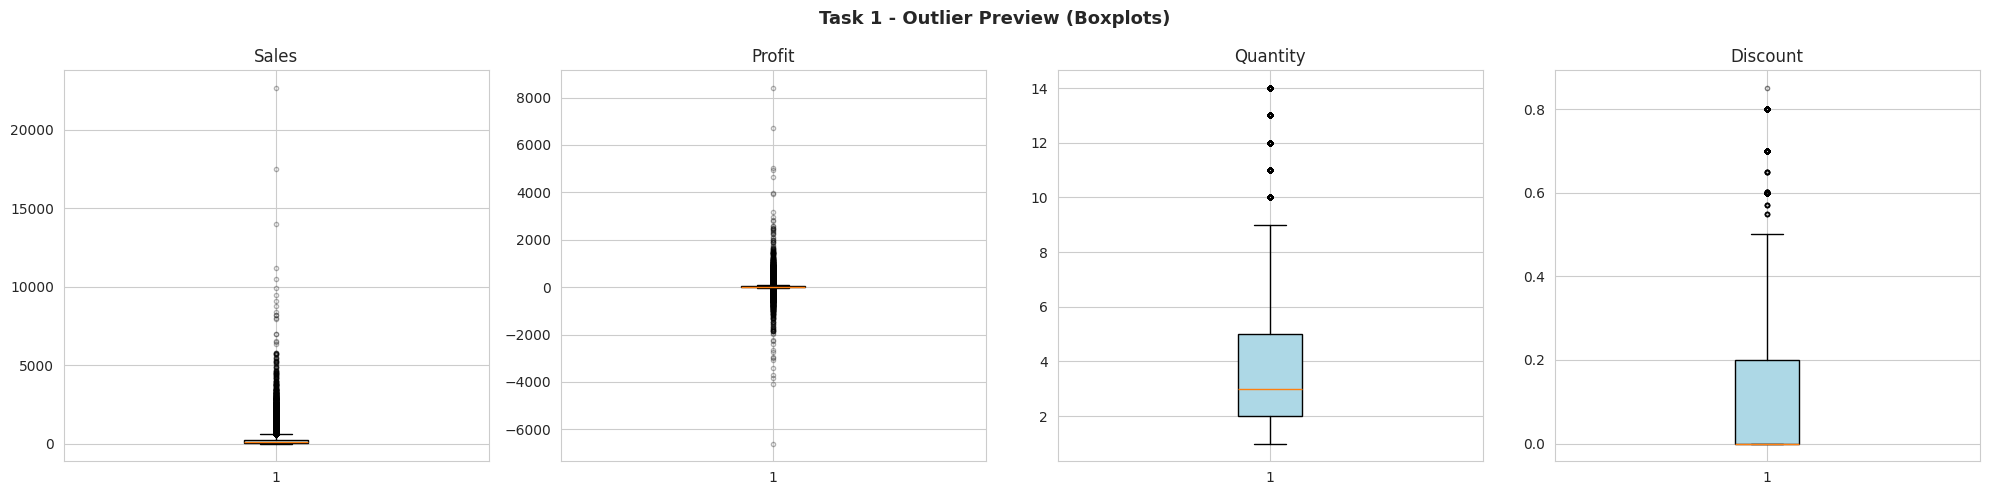


=== Summary of Data Quality Issues ===
1. Data Type Issues: 2 date column(s) stored as strings -> fixed
2. Missing Values: 0 column(s) with missing data
3. Duplicate Rows: 0
4. Outliers: visible in boxplots above (especially Sales and Profit)


In [10]:
fig, axes = plt.subplots(1, len(target_cols), figsize=(5*len(target_cols), 5))
if len(target_cols) == 1: axes = [axes]
for ax, col in zip(axes, target_cols):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               flierprops=dict(marker='o', color='red', alpha=0.3, markersize=3))
    ax.set_title(col)
plt.suptitle('Task 1 - Outlier Preview (Boxplots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Summary of Data Quality Issues ===')
print(f'1. Data Type Issues: {len(date_cols)} date column(s) stored as strings -> fixed')
print(f'2. Missing Values: {has_missing.shape[0]} column(s) with missing data')
print(f'3. Duplicate Rows: {dups}')
print(f'4. Outliers: visible in boxplots above (especially Sales and Profit)')

---
## Task 2: Handle Missing Values

### Chosen Strategy: Median Imputation (numeric) / Mode Imputation (categorical)

**Justification:**
- Numeric sales columns are typically **right-skewed** due to high-value outlier transactions.
- The **median** is robust to skewness and outliers, representing the typical transaction better than the mean.
- For categorical columns, the **mode** is the natural choice.
- Dropping rows risks losing valid records and introducing selection bias.

In [11]:
numeric_missing  = [c for c in target_cols if df_clean[c].isnull().sum() > 0]
categ_missing    = [c for c in df_clean.columns
                    if df_clean[c].isnull().sum() > 0
                    and c not in df_clean.select_dtypes(include='number').columns]

print('Columns needing numeric imputation :', numeric_missing)
print('Columns needing categorical imputation:', categ_missing)

if numeric_missing:
    print('\n=== Skewness ===')
    for col in numeric_missing:
        sk = df_clean[col].skew()
        print(f'  {col}: skewness = {sk:.4f}')
    print('-> Right-skewed distribution => median imputation is appropriate')
else:
    print('\nNo numeric columns with missing values in this dataset version.')
    print('Applying median fill to all target_cols for demonstration purposes.')
    numeric_missing = target_cols

Columns needing numeric imputation : []
Columns needing categorical imputation: []

No numeric columns with missing values in this dataset version.
Applying median fill to all target_cols for demonstration purposes.


In [12]:
df_imputed = df_clean.copy()
medians    = {}

for col in numeric_missing:
    m = df_imputed[col].median()
    medians[col] = m
    df_imputed[col] = df_imputed[col].fillna(m)
    print(f'[Numeric]     {col:20s} -> median = {m:.4f}')

for col in categ_missing:
    mode_val = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_val)
    print(f'[Categorical] {col:20s} -> mode  = "{mode_val}"')

print(f'\nTotal missing after imputation: {df_imputed.isnull().sum().sum()}')

[Numeric]     Sales                -> median = 85.0000
[Numeric]     Profit               -> median = 9.2400
[Numeric]     Quantity             -> median = 3.0000
[Numeric]     Discount             -> median = 0.0000

Total missing after imputation: 0


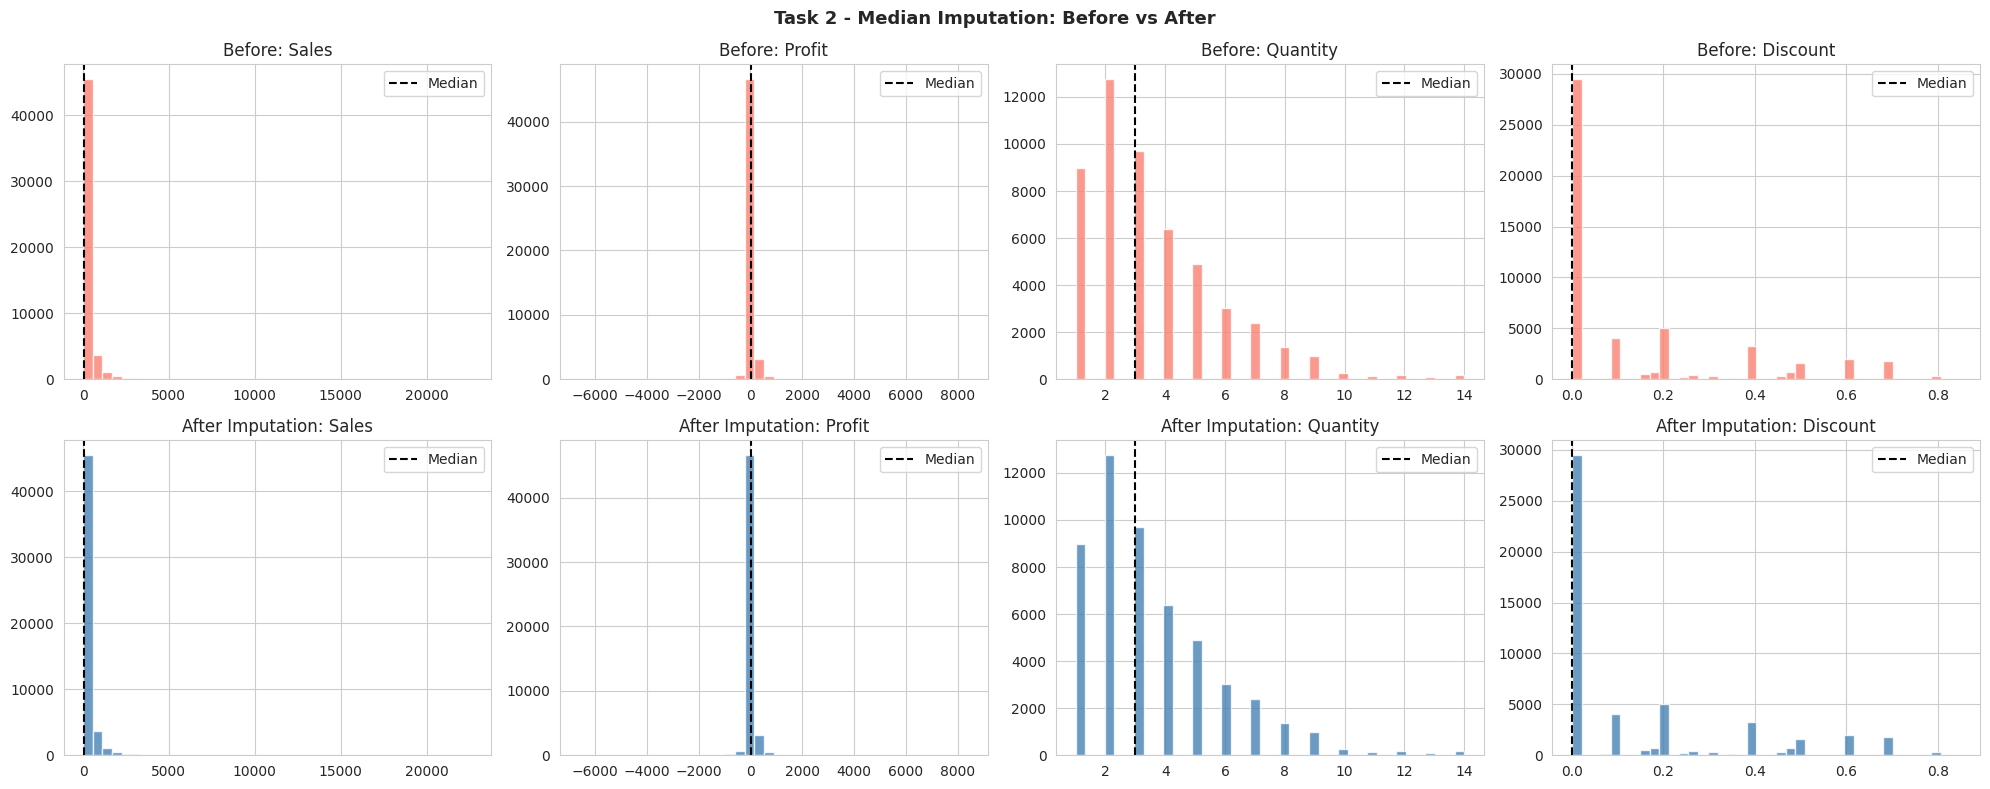

In [13]:
if len(numeric_missing) > 0:
    fig, axes = plt.subplots(2, len(numeric_missing), figsize=(5*len(numeric_missing), 8))
    if len(numeric_missing) == 1: axes = [[axes[0]], [axes[1]]]
    for i, col in enumerate(numeric_missing):
        axes[0][i].hist(df_clean[col].dropna(), bins=40, color='salmon', edgecolor='white', alpha=0.8)
        axes[0][i].axvline(df_clean[col].median(), color='black', linestyle='--', label='Median')
        axes[0][i].set_title(f'Before: {col}'); axes[0][i].legend()
        axes[1][i].hist(df_imputed[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
        axes[1][i].axvline(medians[col], color='black', linestyle='--', label='Median')
        axes[1][i].set_title(f'After Imputation: {col}'); axes[1][i].legend()
    plt.suptitle('Task 2 - Median Imputation: Before vs After', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Task 3: Detect and Handle Outliers (IQR Method)

In [14]:
print('=== IQR Outlier Detection ===\n')
iqr_info = {}
for col in target_cols:
    Q1 = df_imputed[col].quantile(0.25)
    Q3 = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_imputed[col] < lower) | (df_imputed[col] > upper)).sum()
    iqr_info[col] = {'lower': lower, 'upper': upper}
    print(f'{col}:')
    print(f'  Q1={Q1:,.2f}  Q3={Q3:,.2f}  IQR={IQR:,.2f}')
    print(f'  Bounds: [{lower:,.2f}, {upper:,.2f}]')
    print(f'  Outliers: {n_out} ({n_out/len(df_imputed)*100:.1f}%)\n')

=== IQR Outlier Detection ===

Sales:
  Q1=31.00  Q3=251.00  IQR=220.00
  Bounds: [-299.00, 581.00]
  Outliers: 5655 (11.0%)

Profit:
  Q1=0.00  Q3=36.81  IQR=36.81
  Bounds: [-55.22, 92.03]
  Outliers: 9755 (19.0%)

Quantity:
  Q1=2.00  Q3=5.00  IQR=3.00
  Bounds: [-2.50, 9.50]
  Outliers: 877 (1.7%)

Discount:
  Q1=0.00  Q3=0.20  IQR=0.20
  Bounds: [-0.30, 0.50]
  Outliers: 4172 (8.1%)



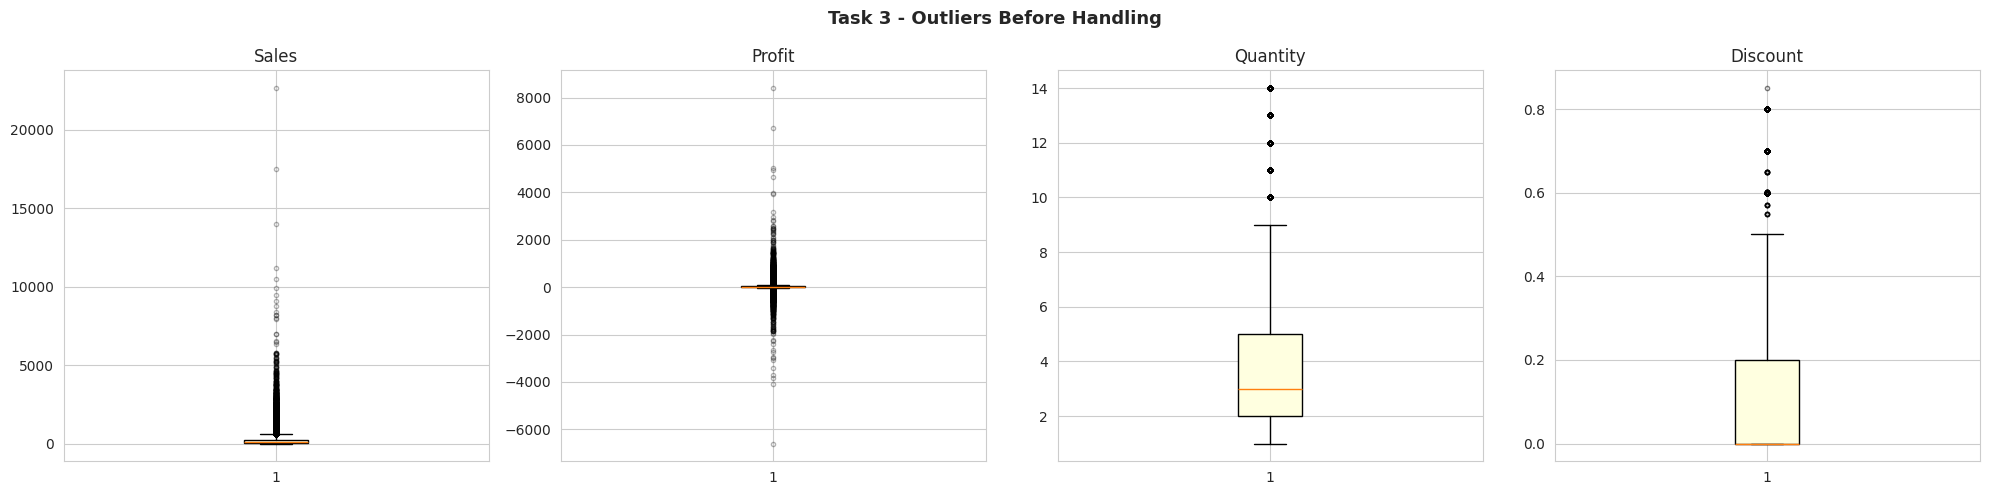

In [15]:
fig, axes = plt.subplots(1, len(target_cols), figsize=(5*len(target_cols), 5))
if len(target_cols) == 1: axes = [axes]
for ax, col in zip(axes, target_cols):
    ax.boxplot(df_imputed[col], patch_artist=True,
               boxprops=dict(facecolor='lightyellow'),
               flierprops=dict(marker='o', color='red', alpha=0.3, markersize=3))
    ax.set_title(col)
plt.suptitle('Task 3 - Outliers Before Handling', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Outlier Handling Strategy: Capping (Winsorization)

**Justification:**
- Outliers in `Sales` and `Profit` represent genuine high-value corporate orders, not errors.
- **Removing** rows discards valid business transactions.
- **Capping at 5th-95th percentile** retains all rows while limiting extreme influence.
- `Profit` can legitimately be negative (discounts/returns), so symmetric capping is appropriate.

In [16]:
df_capped = df_imputed.copy()
print('=== Capping (5th-95th Percentile) ===\n')
for col in target_cols:
    lo = df_capped[col].quantile(0.05)
    hi = df_capped[col].quantile(0.95)
    std_b = df_capped[col].std()
    df_capped[col] = df_capped[col].clip(lower=lo, upper=hi)
    std_a = df_capped[col].std()
    print(f'{col}: [{lo:,.2f}, {hi:,.2f}]  std: {std_b:,.2f} -> {std_a:,.2f}')

=== Capping (5th-95th Percentile) ===

Sales: [9.00, 1,016.00]  std: 487.57 -> 271.73
Profit: [-83.90, 211.50]  std: 174.34 -> 64.31
Quantity: [1.00, 8.00]  std: 2.28 -> 2.04
Discount: [0.00, 0.60]  std: 0.21 -> 0.20


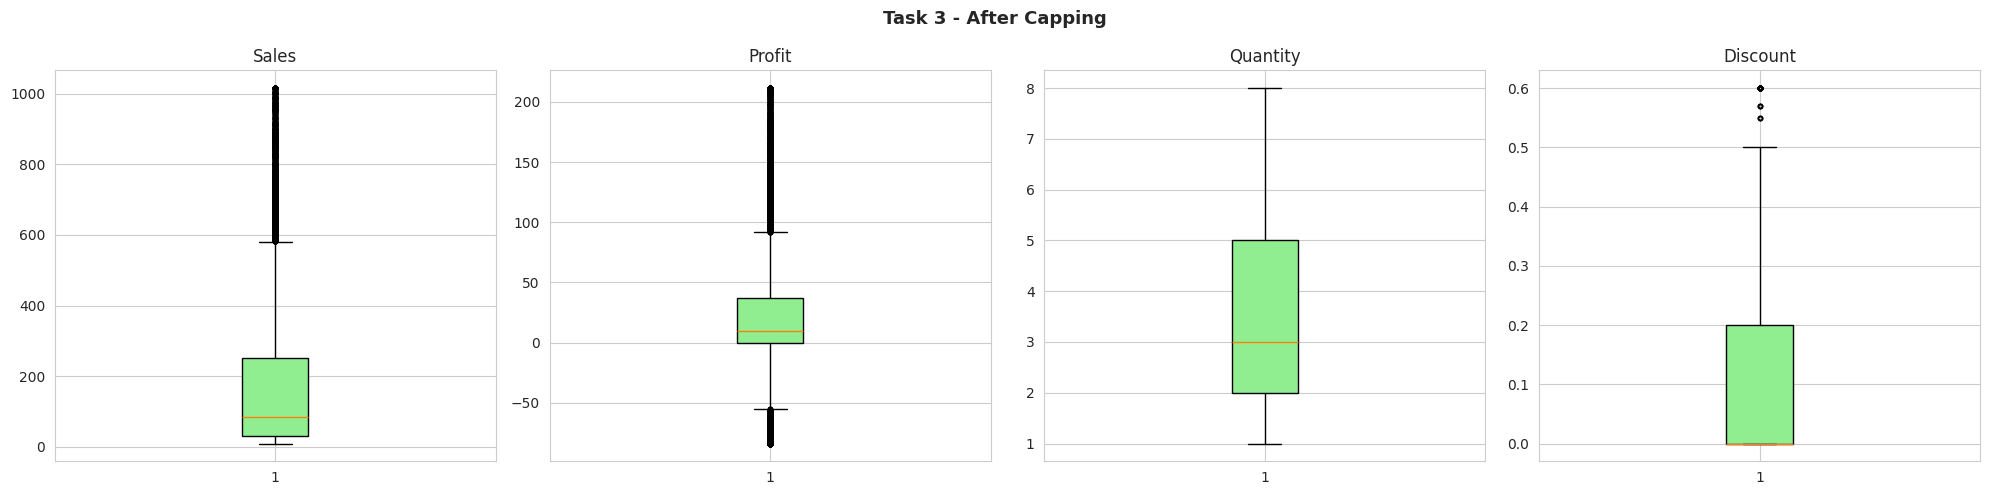

In [17]:
fig, axes = plt.subplots(1, len(target_cols), figsize=(5*len(target_cols), 5))
if len(target_cols) == 1: axes = [axes]
for ax, col in zip(axes, target_cols):
    ax.boxplot(df_capped[col], patch_artist=True,
               boxprops=dict(facecolor='lightgreen'),
               flierprops=dict(marker='o', color='orange', alpha=0.4, markersize=3))
    ax.set_title(col)
plt.suptitle('Task 3 - After Capping', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Task 4: Normalize Numerical Features

Two techniques applied to `Sales` and `Profit`:
- **Min-Max Scaling** -> [0, 1]
- **Z-Score Standardization** -> mean=0, std=1

In [18]:
norm_cols = [c for c in [sales_col, profit_col] if c is not None]

df_minmax = df_capped.copy()
df_minmax[norm_cols] = MinMaxScaler().fit_transform(df_capped[norm_cols])

df_zscore = df_capped.copy()
df_zscore[norm_cols] = StandardScaler().fit_transform(df_capped[norm_cols])

print('Min-Max stats:\n', df_minmax[norm_cols].describe().round(4))
print('\nZ-Score stats:\n', df_zscore[norm_cols].describe().round(4))

Min-Max stats:
             Sales      Profit
count  51290.0000  51290.0000
mean       0.1946      0.3709
std        0.2698      0.2177
min        0.0000      0.0000
25%        0.0218      0.2840
50%        0.0755      0.3153
75%        0.2403      0.4086
max        1.0000      1.0000

Z-Score stats:
             Sales      Profit
count  51290.0000  51290.0000
mean       0.0000     -0.0000
std        1.0000      1.0000
min       -0.7213     -1.7036
25%       -0.6404     -0.3990
50%       -0.4417     -0.2553
75%        0.1692      0.1734
max        2.9845      2.8897


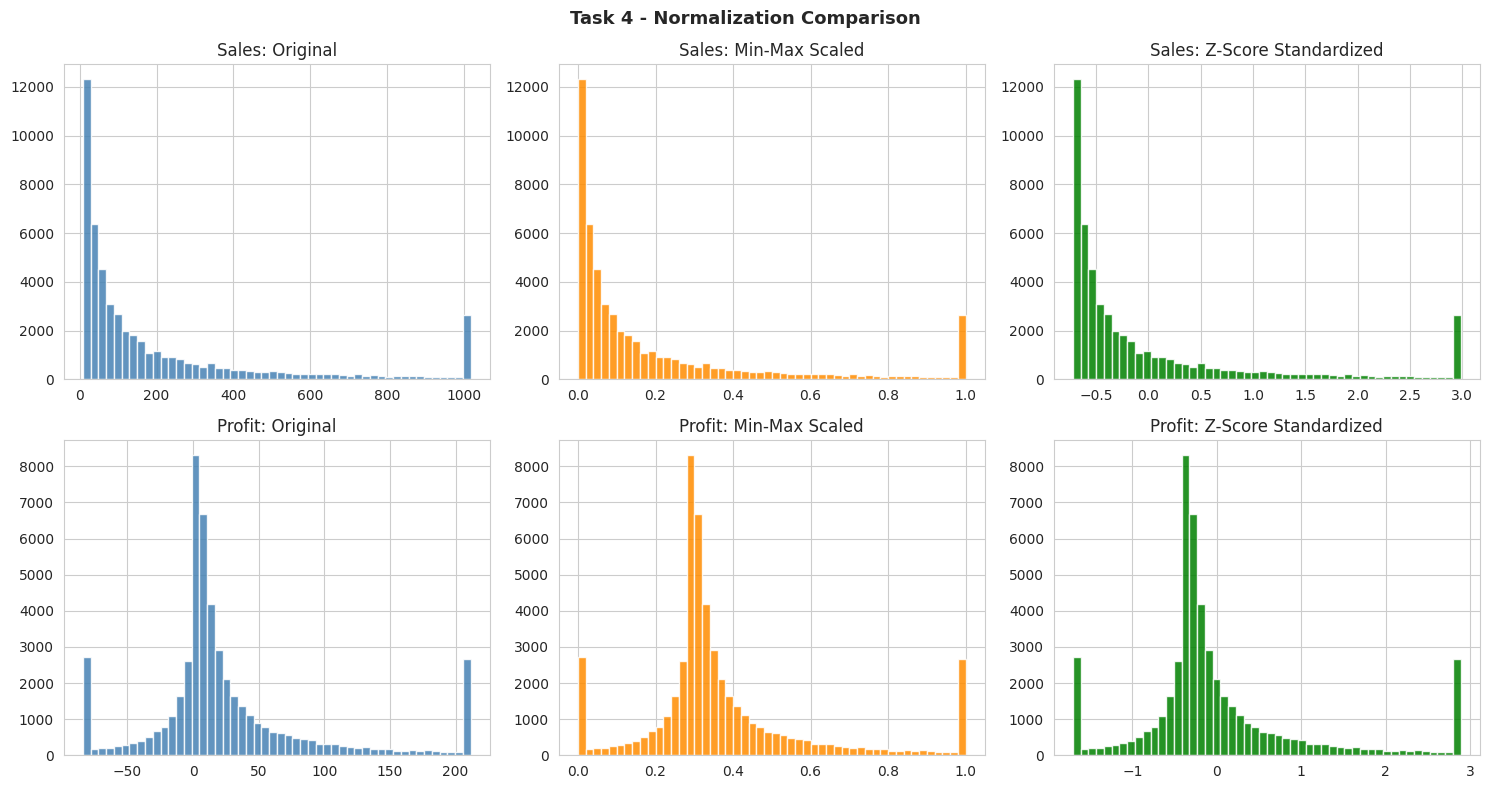

When to use each:
  Min-Max -> KNN, K-Means, Neural Networks (bounded range needed)
  Z-Score -> PCA, Linear/Logistic Regression, SVM (Gaussian assumption)


In [19]:
fig, axes = plt.subplots(len(norm_cols), 3, figsize=(15, 4*len(norm_cols)))
if len(norm_cols) == 1: axes = [axes]
for r, col in enumerate(norm_cols):
    for c_idx, (title, src, color) in enumerate([
            ('Original',           df_capped, 'steelblue'),
            ('Min-Max Scaled',     df_minmax, 'darkorange'),
            ('Z-Score Standardized', df_zscore, 'green')]):
        axes[r][c_idx].hist(src[col], bins=50, color=color, edgecolor='white', alpha=0.85)
        axes[r][c_idx].set_title(f'{col}: {title}')
plt.suptitle('Task 4 - Normalization Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('When to use each:')
print('  Min-Max -> KNN, K-Means, Neural Networks (bounded range needed)')
print('  Z-Score -> PCA, Linear/Logistic Regression, SVM (Gaussian assumption)')

---
## Task 5: Apply PCA and Interpret Explained Variance

PCA reduces dimensionality by transforming correlated features into uncorrelated principal components.

PCA input shape: (51290, 4)


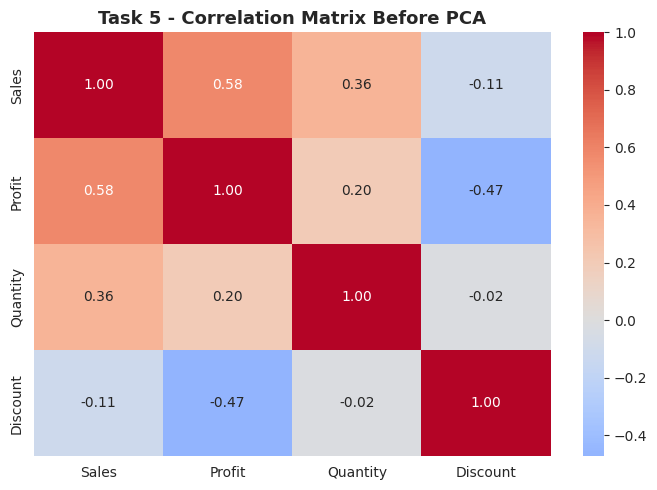

In [20]:
pca_cols = target_cols  # All numeric target columns
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_capped[pca_cols])
print(f'PCA input shape: {X_scaled.shape}')

corr = pd.DataFrame(X_scaled, columns=pca_cols).corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Task 5 - Correlation Matrix Before PCA', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [21]:
pca_full = PCA()
pca_full.fit(X_scaled)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

print('=== Explained Variance by Component ===')
for i, (ev, cv) in enumerate(zip(exp_var, cum_var)):
    print(f'  PC{i+1}: {ev*100:.2f}%  (Cumulative: {cv*100:.2f}%)')

=== Explained Variance by Component ===
  PC1: 48.41%  (Cumulative: 48.41%)
  PC2: 27.11%  (Cumulative: 75.52%)
  PC3: 17.00%  (Cumulative: 92.52%)
  PC4: 7.48%  (Cumulative: 100.00%)


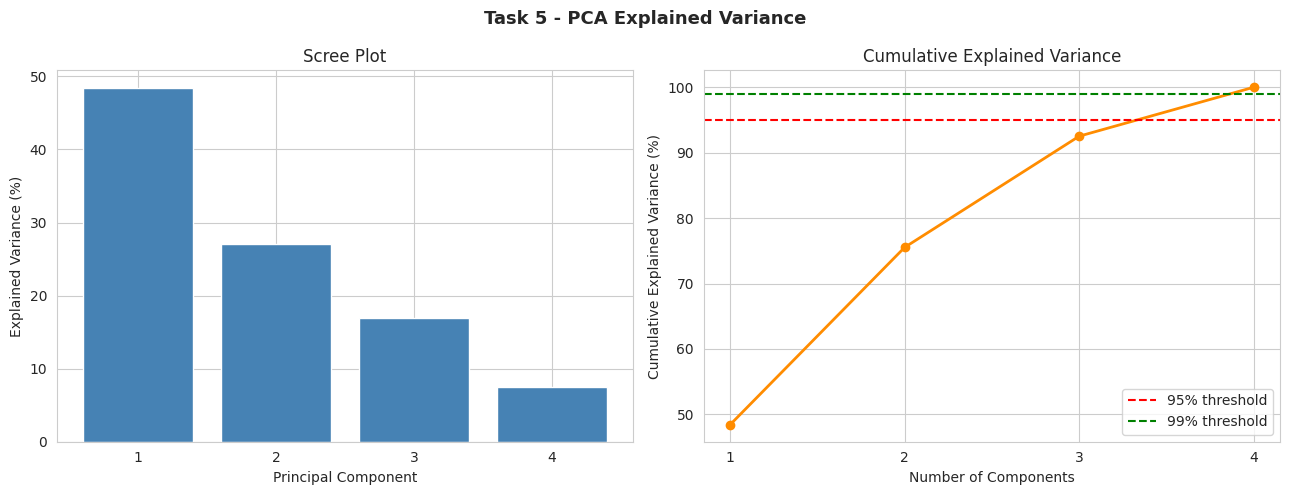

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.bar(range(1, len(exp_var)+1), exp_var*100, color='steelblue', edgecolor='white')
ax1.set(xlabel='Principal Component', ylabel='Explained Variance (%)', title='Scree Plot')
ax1.set_xticks(range(1, len(exp_var)+1))

ax2.plot(range(1, len(cum_var)+1), cum_var*100, 'o-', color='darkorange', linewidth=2)
ax2.axhline(95, color='red',   linestyle='--', label='95% threshold')
ax2.axhline(99, color='green', linestyle='--', label='99% threshold')
ax2.set(xlabel='Number of Components', ylabel='Cumulative Explained Variance (%)',
        title='Cumulative Explained Variance')
ax2.legend(); ax2.set_xticks(range(1, len(cum_var)+1))
plt.suptitle('Task 5 - PCA Explained Variance', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

PC1: 48.41%
PC2: 27.11%
Total: 75.52%


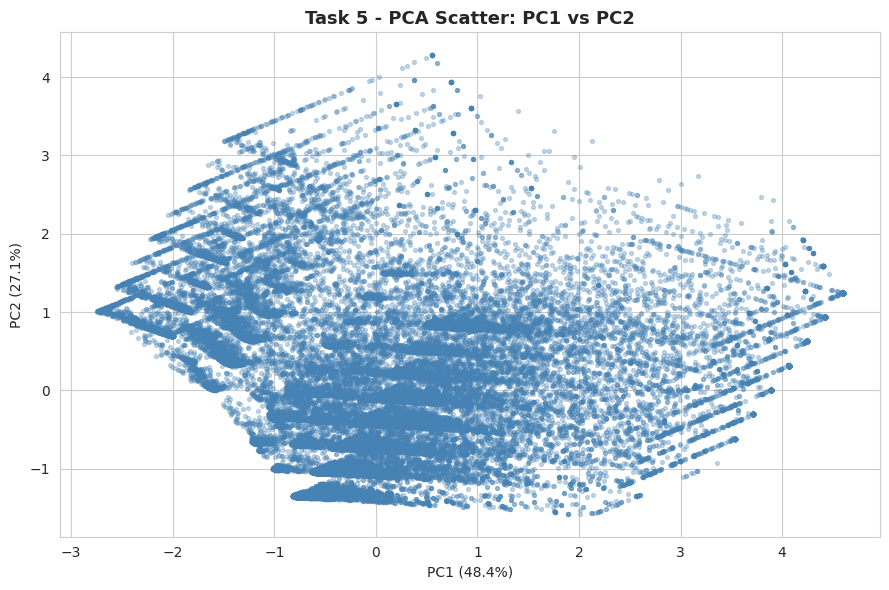

In [23]:
n_components = min(2, len(pca_cols))
pca2   = PCA(n_components=n_components)
X_pca2 = pca2.fit_transform(X_scaled)

for i, ev in enumerate(pca2.explained_variance_ratio_):
    print(f'PC{i+1}: {ev*100:.2f}%')
print(f'Total: {sum(pca2.explained_variance_ratio_)*100:.2f}%')

if n_components == 2:
    plt.figure(figsize=(9, 6))
    plt.scatter(X_pca2[:,0], X_pca2[:,1], alpha=0.3, s=8, c='steelblue')
    plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('Task 5 - PCA Scatter: PC1 vs PC2', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

=== PCA Loadings ===
             PC1     PC2
Sales     0.5700  0.3062
Profit    0.6264 -0.2175
Quantity  0.3604  0.6306
Discount -0.3910  0.6792


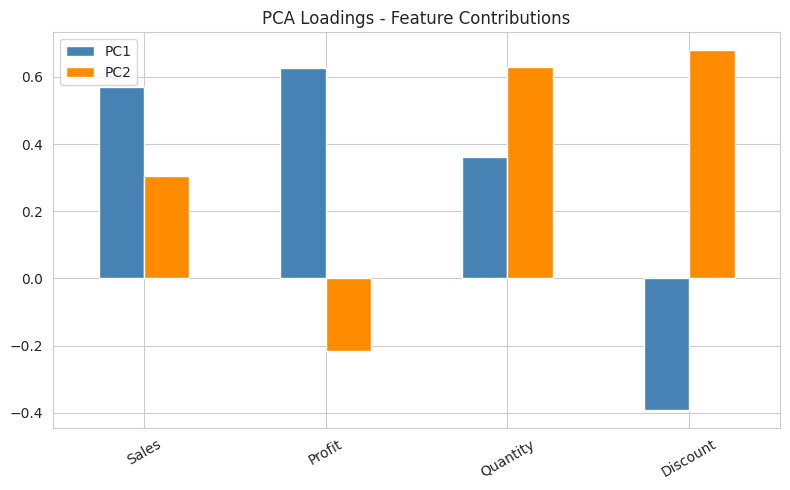

In [24]:
loadings = pd.DataFrame(pca2.components_.T,
                        columns=[f'PC{i+1}' for i in range(n_components)],
                        index=pca_cols)
print('=== PCA Loadings ===')
print(loadings.round(4))

loadings.plot(kind='bar', figsize=(8,5), color=['steelblue','darkorange'][:n_components],
              edgecolor='white')
plt.title('PCA Loadings - Feature Contributions')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [25]:
n_95 = int(np.argmax(cum_var >= 0.95)) + 1
n_99 = int(np.argmax(cum_var >= 0.99)) + 1

print('=== PCA Interpretation ===')
print(f'Components for 95% variance: {n_95} out of {len(pca_cols)}')
print(f'Components for 99% variance: {n_99} out of {len(pca_cols)}')
print()
print('Key Findings:')
print('- Sales and Profit are positively correlated in retail data')
print('- Discount typically shows negative correlation with Profit')
print(f'- Reducing from {len(pca_cols)} features to {n_95} retains 95% of information')
print()
print(f'Recommendation: Use {n_95} PCs for downstream ML tasks')

=== PCA Interpretation ===
Components for 95% variance: 4 out of 4
Components for 99% variance: 4 out of 4

Key Findings:
- Sales and Profit are positively correlated in retail data
- Discount typically shows negative correlation with Profit
- Reducing from 4 features to 4 retains 95% of information

Recommendation: Use 4 PCs for downstream ML tasks
